<a href="https://colab.research.google.com/github/SulaimanTajuddin/EDA-JB-Property-Transaction/blob/main/2026_EDA_JB_Properties.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA & Analysis for Johor Bahru Properties**


**Import necessary libraries:**

In [1]:
import pandas as pd # for data manipulation and analysis
import numpy as np
import missingno as msno # uncovering missing data patterns in datasets
import matplotlib.pyplot as plt # for plotting graph
import seaborn as sns
from sklearn.ensemble import IsolationForest

**Load data into pandas dataframe:**

In [2]:
df = pd.read_csv('Open Transaction Data (1).csv', sep='\t')

**Analyze raw data:**

In [3]:
df.head()

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,Unnamed: 13
0,1 - 1 1/2 Storey Semi-Detached,Johor Bahru,Bandar Johor Bahru,FRESH BREEZE,JLN CHANTEK,December 2021,Freehold,472.23,sq.m,89,sq.m,,"RM700,000.00",NaN
1,1 - 1 1/2 Storey Semi-Detached,Johor Bahru,Bandar Johor Bahru,FRESH BREEZE,JLN MAS,July 2022,Freehold,348.19,sq.m,89,sq.m,,"RM750,000.00",NaN
2,1 - 1 1/2 Storey Semi-Detached,Johor Bahru,Bandar Johor Bahru,FRESH BREEZE,JLN SEPOI,January 2025,Freehold,384.43,sq.m,83,sq.m,,"RM920,000.00",NaN
3,1 - 1 1/2 Storey Semi-Detached,Johor Bahru,Bandar Johor Bahru,KAW ABDUL SAMAD/MARIAMAH,JLN ABDUL SAMAD / LRG 2B,August 2024,Freehold,416.29,sq.m,128,sq.m,,"RM600,000.00",NaN
4,1 - 1 1/2 Storey Semi-Detached,Johor Bahru,Bandar Johor Bahru,KAW ABDUL SAMAD/MARIAMAH,JLN DAPAT,September 2024,Freehold,645.28,sq.m,175,sq.m,,"RM900,000.00",NaN


In [4]:
df.dtypes

,0
Property Type,object
District,object
Mukim,object
Scheme Name/Area,object
Road Name,object
"Month, Year of Transaction Date",object
Tenure,object
Land/Parcel Area,object
Unit,object
Main Floor Area,object


<Axes: >

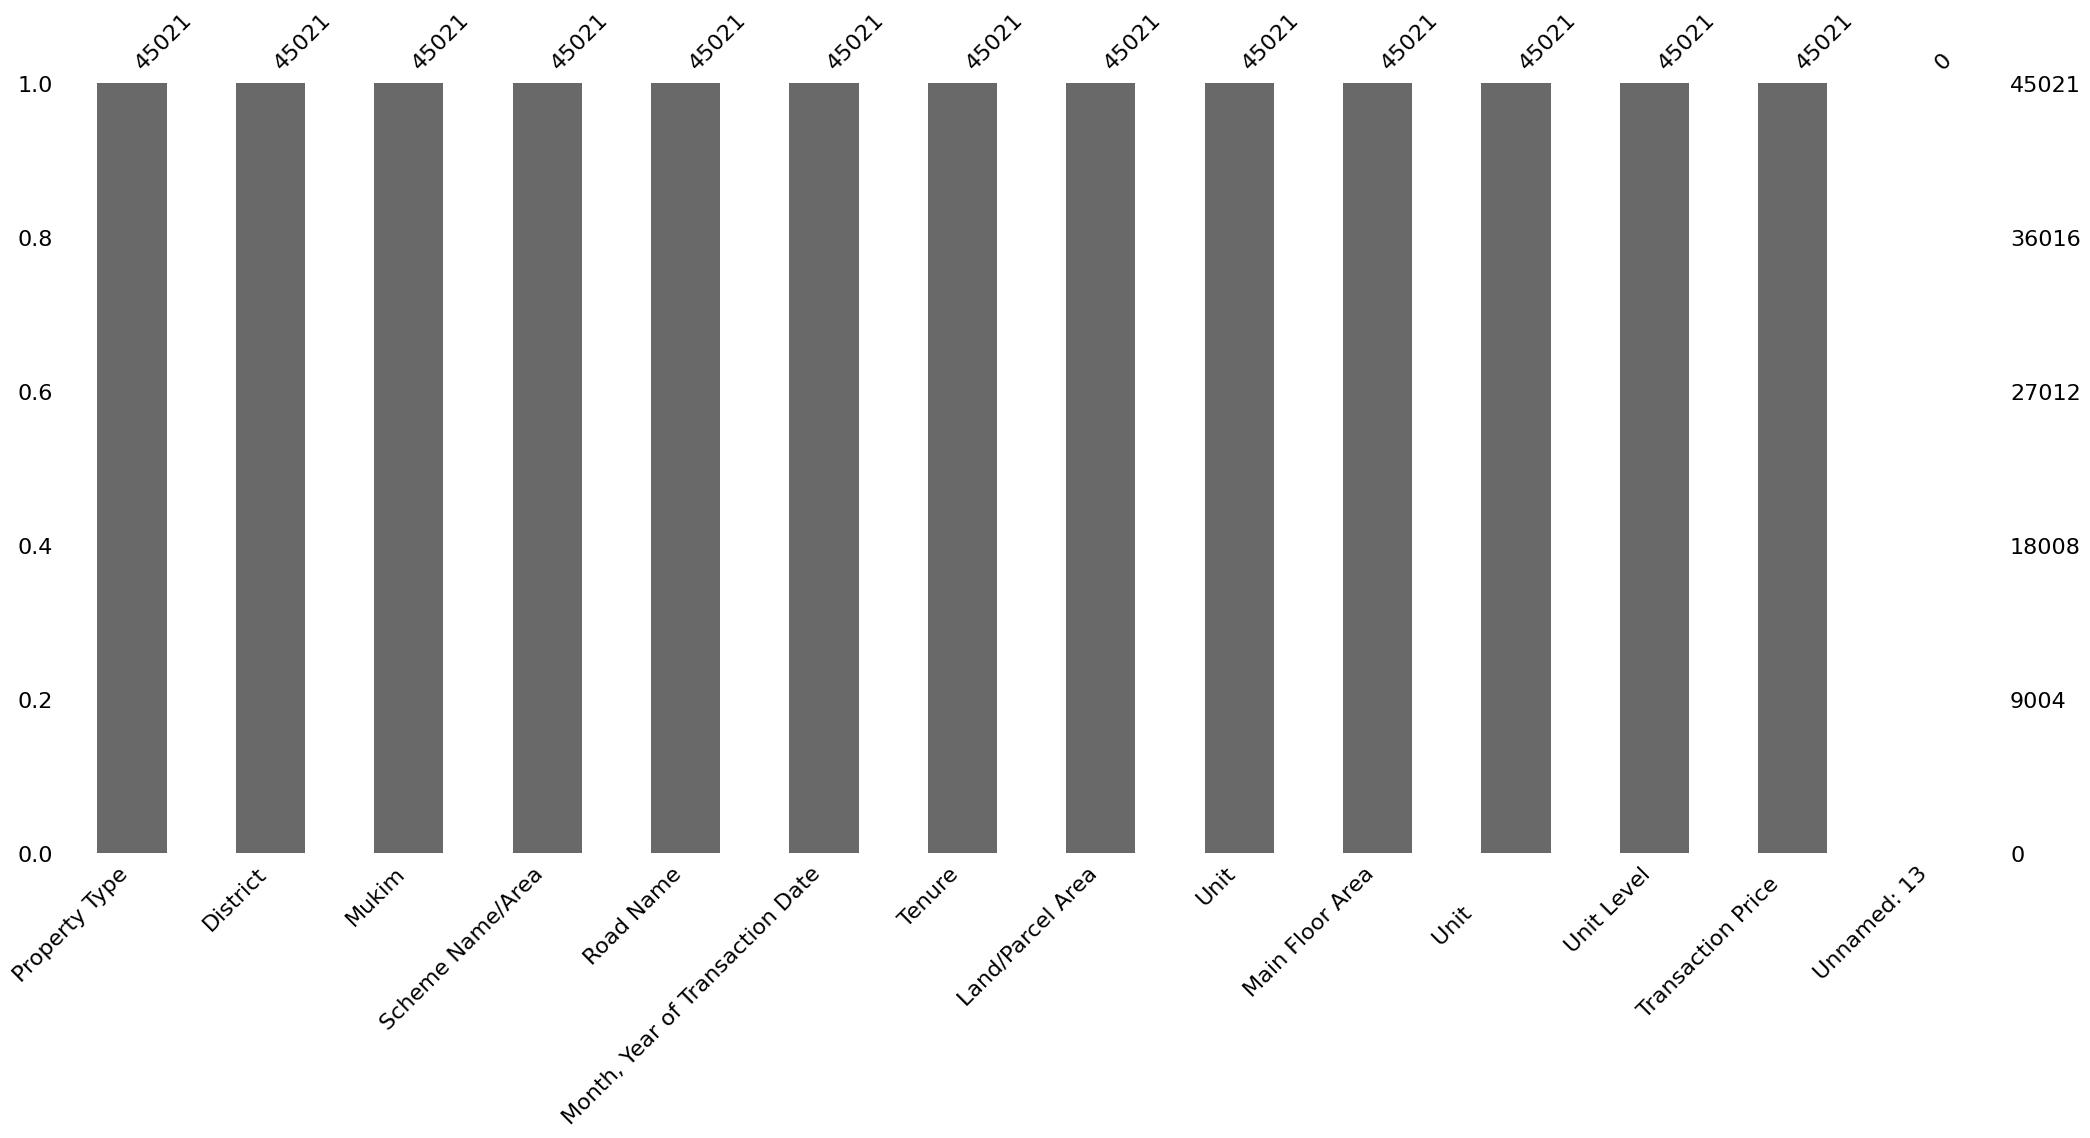

In [5]:
msno.bar(df) # visualizing missing numeric data with bar chart (missingno library)

In [6]:
print("\n(Total no. of rows, Total no. of columns) = " + f"{df.shape}")


(Total no. of rows, Total no. of columns) = (45021, 14)


In [7]:
print("\nExisting column :\n " + f"{df.columns.tolist()}") # inspect column name, view any whitespace


Existing column :
 ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit        ', 'Unit Level', 'Transaction Price  ', 'Unnamed: 13']


In [8]:
df.duplicated().sum() # total count of duplicate rows present in the DataFrame:

np.int64(52)

In [9]:
for i in df.columns: # checking total null values/NaN in a column
    print(i," : ",df[i].isnull().sum()) # OR print(i," : ",df[i].isna().sum())

Property Type  :  0
District  :  0
Mukim  :  0
Scheme Name/Area  :  0
Road Name  :  0
Month, Year of Transaction Date  :  0
Tenure  :  0
Land/Parcel Area  :  0
Unit  :  0
Main Floor Area  :  0
Unit          :  0
Unit Level  :  0
Transaction Price    :  0
Unnamed: 13  :  45021


**Data cleansing and converting:**

In [10]:
df.columns = df.columns.str.strip() # remove leading/trailing spaces in column names and print the output after column stripped
print("\nColumn after stripped :\n" + f"{df.columns.tolist()}\n")


Column after stripped :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price', 'Unnamed: 13']



In [11]:
df = df.dropna(axis=1, how='all') # remove the entire column only if all values are NaN and print the output after removed NaN column:
print("\nResult after remove NaN column :\n"+ f"{df.columns.tolist()}")


Result after remove NaN column :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price']


In [12]:
# Clean and convert 'Transaction Price' to numeric
df['Transaction Price'] = df['Transaction Price'].str.replace('RM', '', regex=False)
df['Transaction Price'] = df['Transaction Price'].str.replace(',', '', regex=False).astype(float)

print(df['Land/Parcel Area'].unique())
print(df['Land/Parcel Area'][df['Land/Parcel Area'] == ''])  # find empty strings

# Clean and convert 'Land/Parcel Area' to numeric
df['Land/Parcel Area'] = df['Land/Parcel Area'].str.replace(',', '', regex=False).astype(float)

print(df['Main Floor Area'].unique())
print(df['Main Floor Area'][df['Main Floor Area'] == ''])  # find empty strings

# Clean and convert 'Main Floor Area' to numeric
df['Main Floor Area'] = df['Main Floor Area'].str.replace('-', '', regex=False)
df['Main Floor Area'] = df['Main Floor Area'].str.replace(',', '', regex=False).replace('', np.nan).astype(float)

['472.23' '348.19' '384.43' ... '90.98' '99.59' '82.16']
Series([], Name: Land/Parcel Area, dtype: object)
['89' '83' '128' '175' '98' '102' '101' '112' '125' '116' '148' '141'
 '190' '97' '100' '127' '84' '138' '94' '104' '130' '174' '73' '117' '183'
 '99' '85' '110' '93' '86' '115' '126' '87' '106' '256' '107' '103' '131'
 '195' '71' '451' '91' '139' '236' '142' '96' '259' '120' '88' '124' '92'
 '68' '78' '77' '111' '90' '210' '135' '79' '189' '46' '59' '52' '60' '51'
 '63' '69' '55' '167' '76' '72' '143' '105' '114' '133' '57' '118' '64'
 '67' '81' '80' '82' '75' '70' '134' '132' '159' '121' '146' '65' '74'
 '61' '156' '145' '95' '123' '154' '181' '186' '108' '66' '62' '140' '144'
 '45' '137' '193' '53' '58' '109' '163' '184' '162' '157' '119' '230'
 '180' '48' '129' '1,359' '122' '49' '155' '153' '225' '158' '177' '113'
 '151' '164' '170' '185' '334' '172' '214' '201' '228' '194' '235' '152'
 '200' '320' '233' '223' '293' '178' '237' '314' '212' '306' '372' '312'
 '216' '265' '226'

**Analyze data after cleansing & converting:**

In [13]:
df.dtypes

,0
Property Type,object
District,object
Mukim,object
Scheme Name/Area,object
Road Name,object
"Month, Year of Transaction Date",object
Tenure,object
Land/Parcel Area,float64
Unit,object
Main Floor Area,float64


<Axes: >

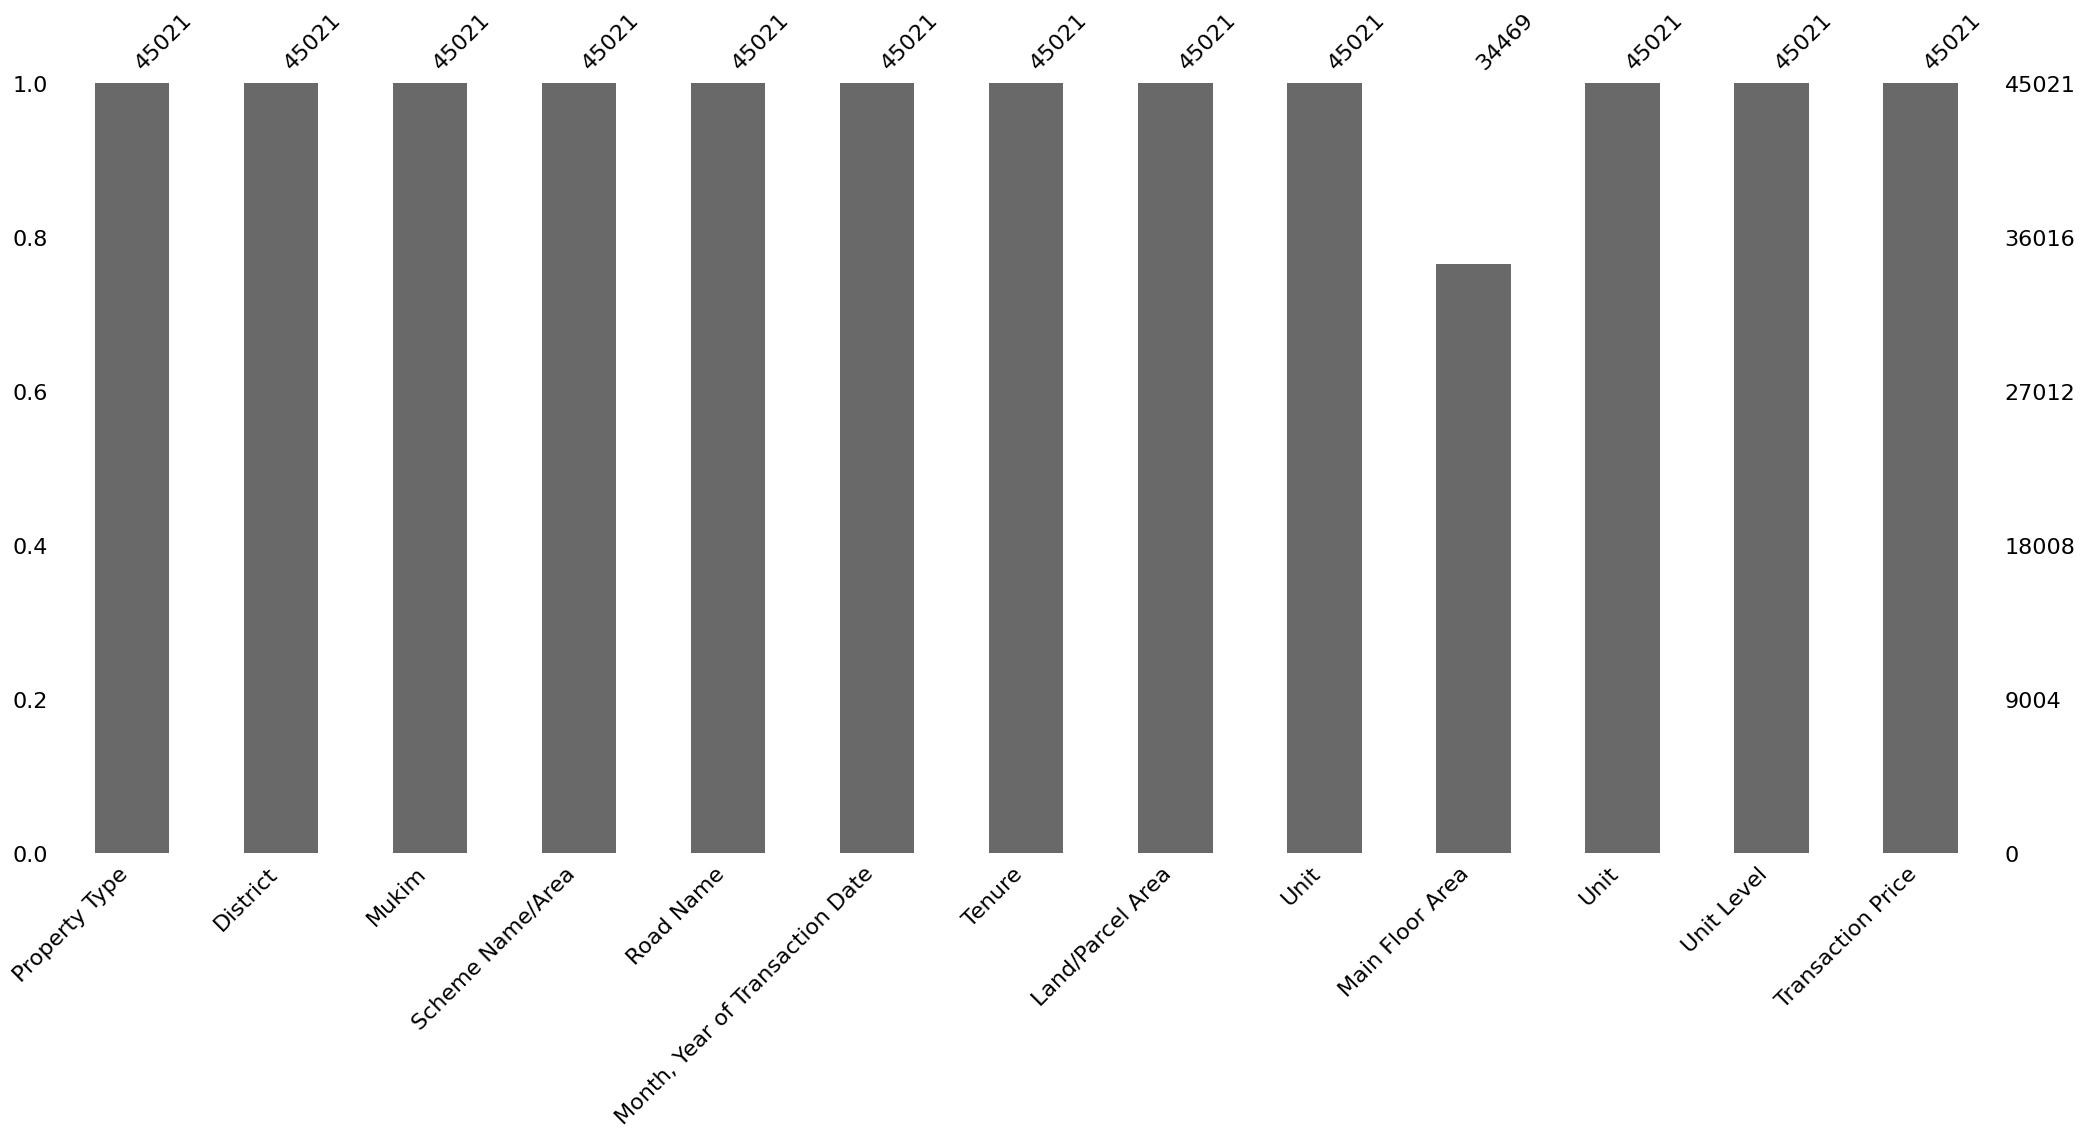

In [14]:
msno.bar(df) # visualizing missing numeric data with bar chart (missingno library)

<Axes: >

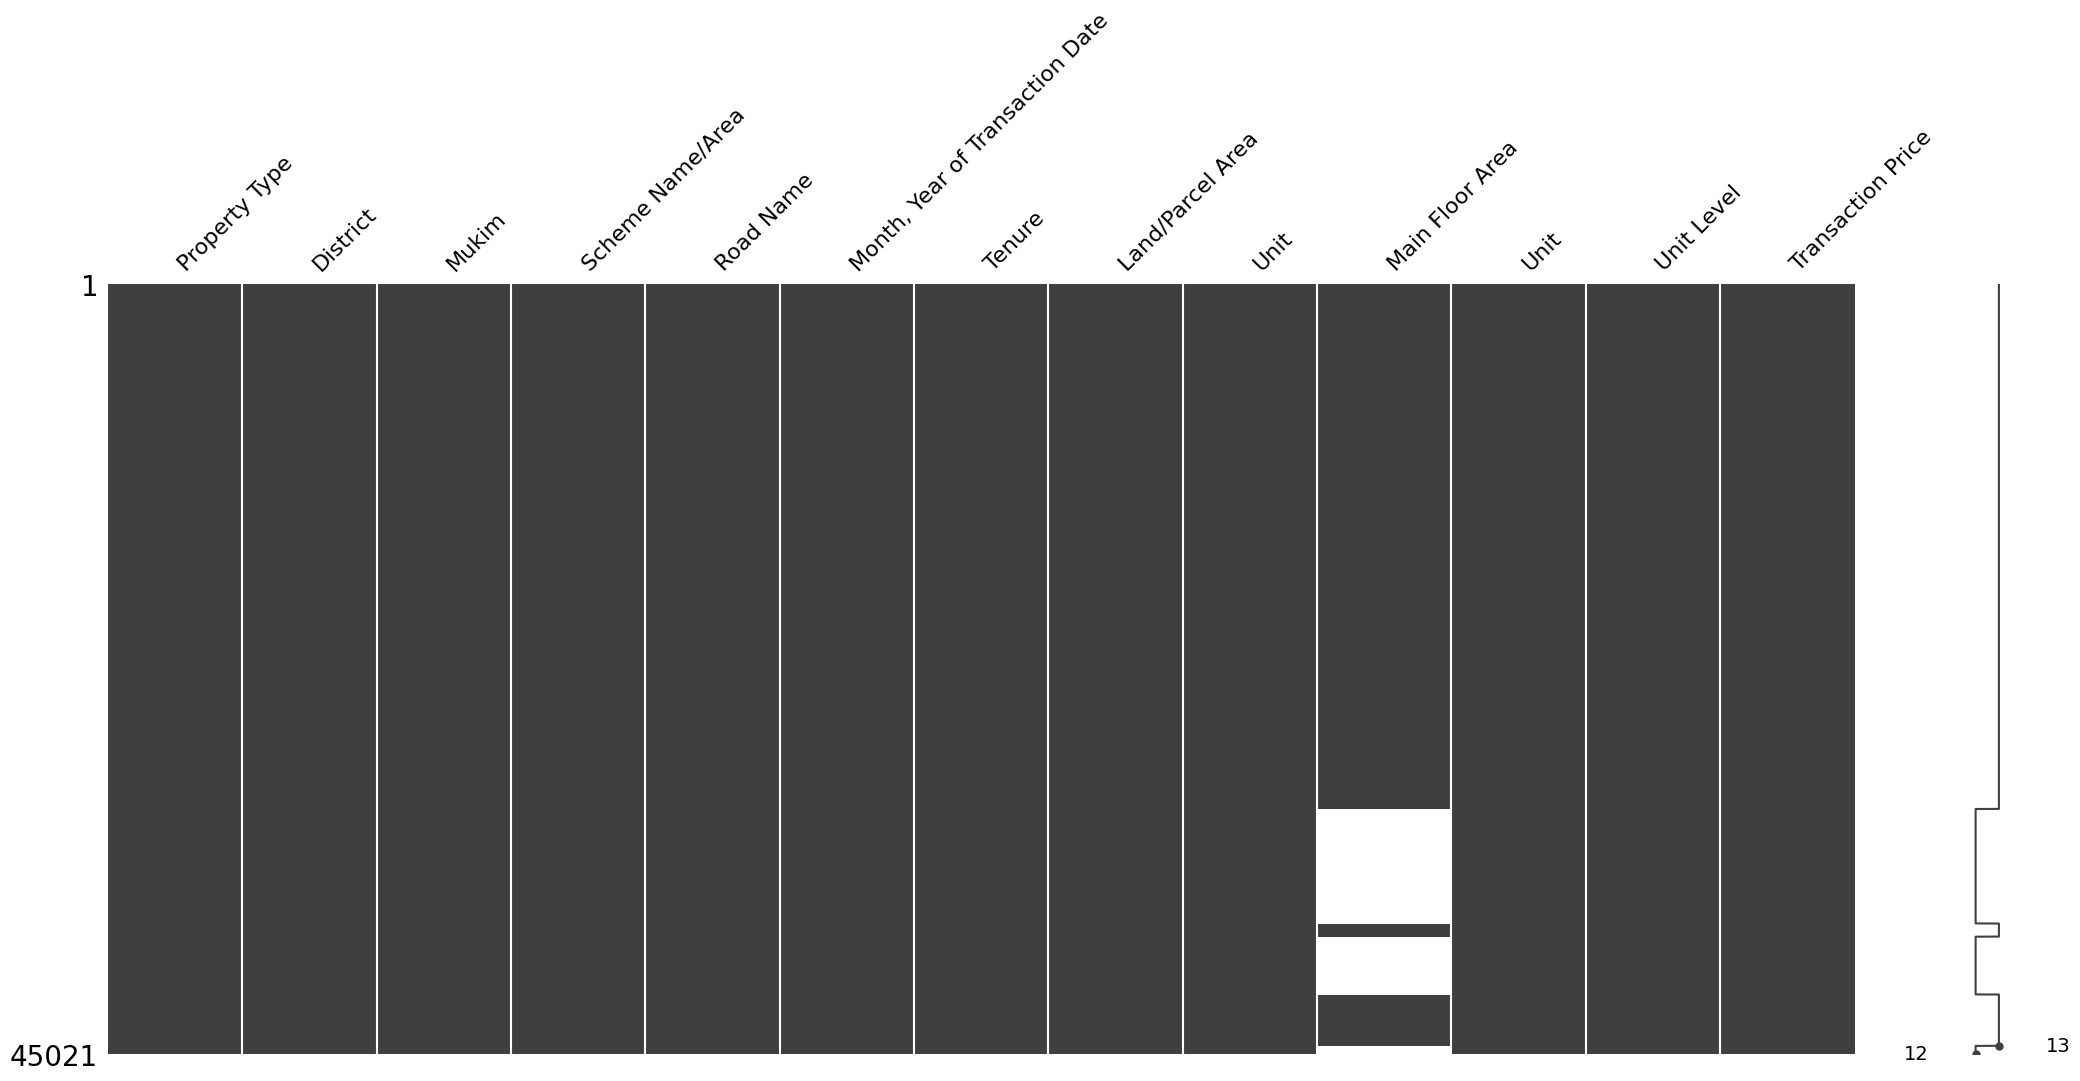

In [15]:
msno.matrix(df)  # visualizing missing numeric data with Matrix plot (missingno library)

In [16]:
for i in df.columns: # Checking total null values/NaN in a column
    print(i," : ",df[i].isnull().sum()) # OR print(i," : ",df[i].isna().sum())

Property Type  :  0
District  :  0
Mukim  :  0
Scheme Name/Area  :  0
Road Name  :  0
Month, Year of Transaction Date  :  0
Tenure  :  0
Land/Parcel Area  :  0
Unit  :  Unit    0
Unit    0
dtype: int64
Main Floor Area  :  10552
Unit  :  Unit    0
Unit    0
dtype: int64
Unit Level  :  0
Transaction Price  :  0


**Anomalies/Outliers detection:**

In [17]:
print('For Transaction Price:')
q1 = df['Transaction Price'].quantile(0.25)
q3 = df['Transaction Price'].quantile(0.75)
iqr = q3 - q1

out_low = q1 - 1.5 * iqr
out_high = q3 + 1.5 * iqr

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")

kaya = df[df['Transaction Price'] == 12288000]

kaya.head()


For Transaction Price:
Q1: 350000.00
Q3: 692000.00
IQR: 342000.00


,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price
37944,Detached,Johor Bahru,Pulai,LEISURE FARM,JLN NURI 6,October 2023,Freehold,4172.0,sq.m,842.0,sq.m,,12288000.0


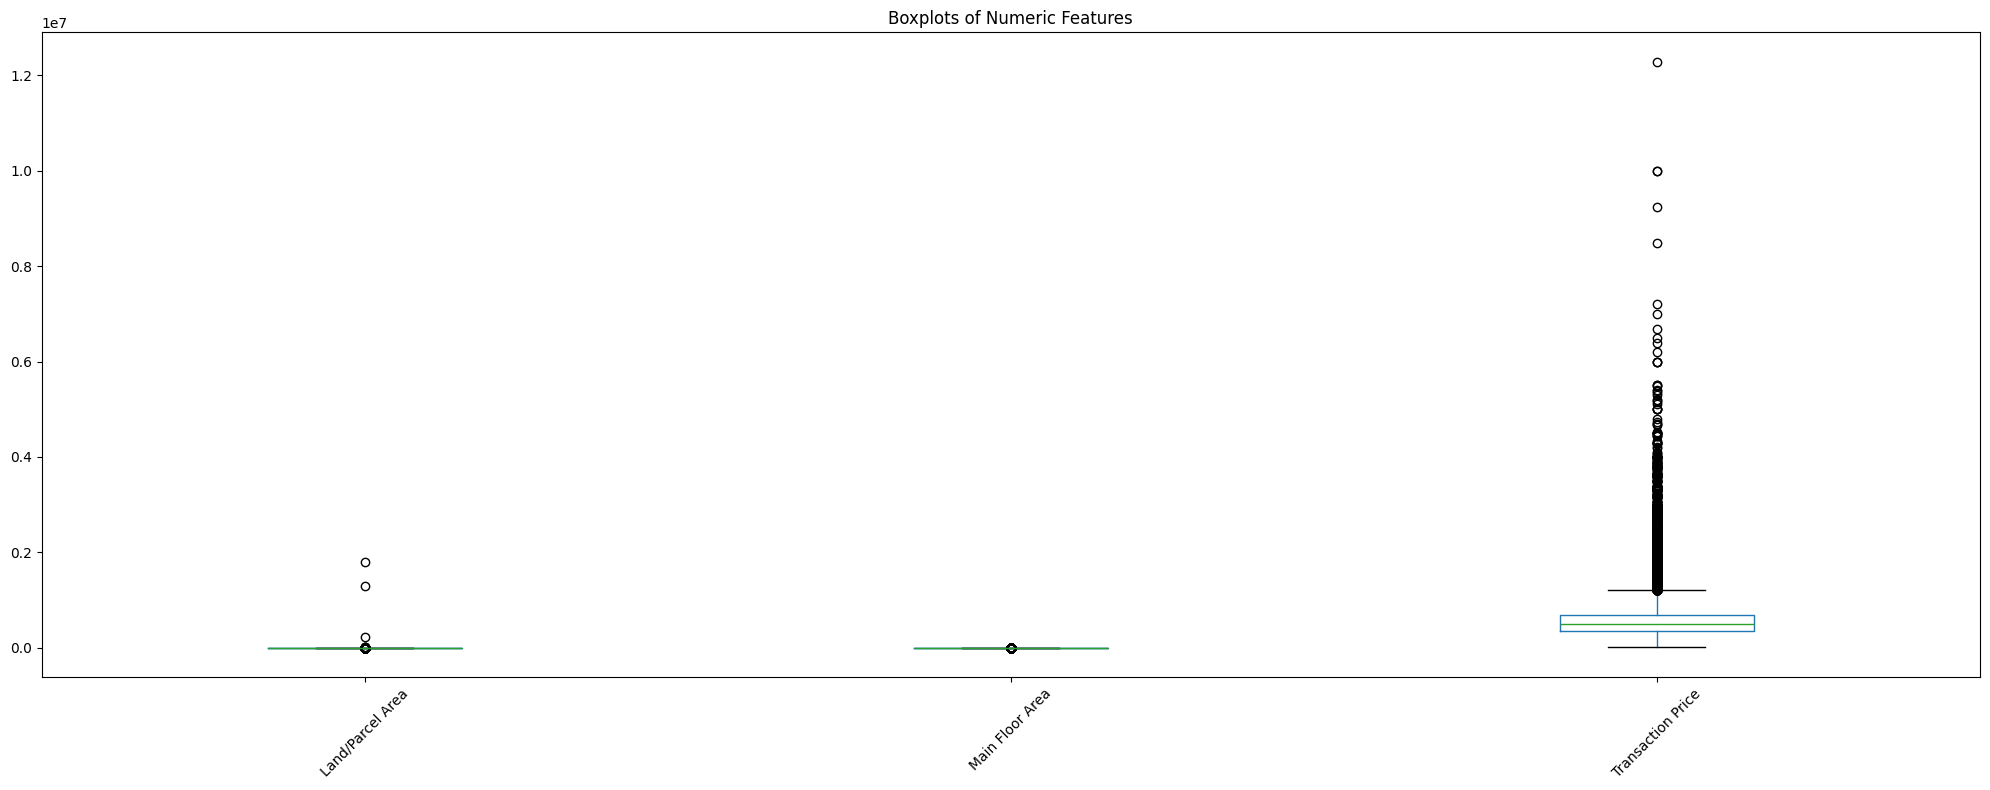

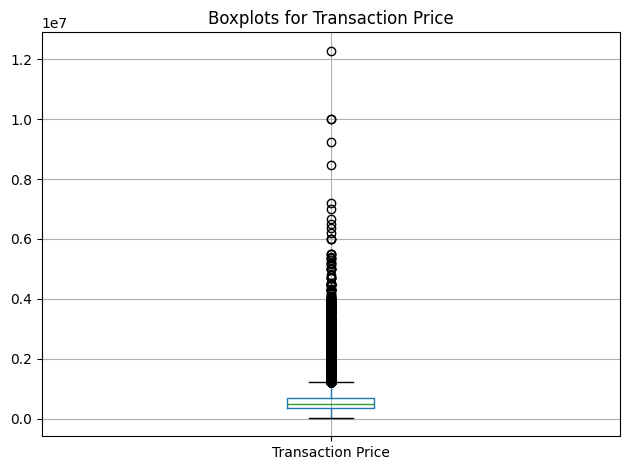

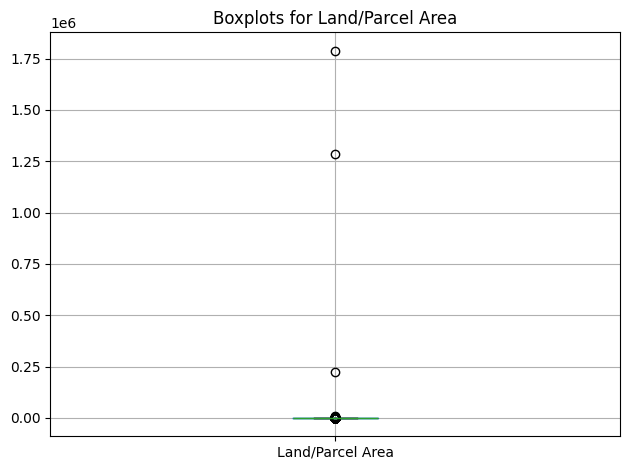

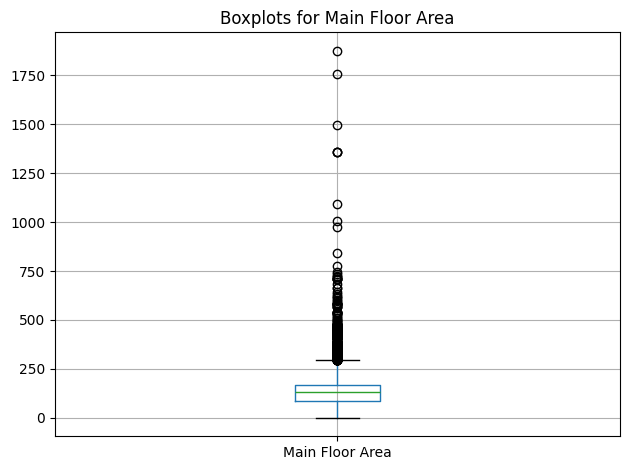






 15672    1788888.0
20369     225161.0
28702    1286882.4
Name: Land/Parcel Area, dtype: float64


 0        472.23
1        348.19
2        384.43
3        416.29
4        645.28
          ...  
45016     95.00
45017     95.00
45018     95.00
45019     95.00
45020     95.00
Name: Land/Parcel Area, Length: 45018, dtype: float64


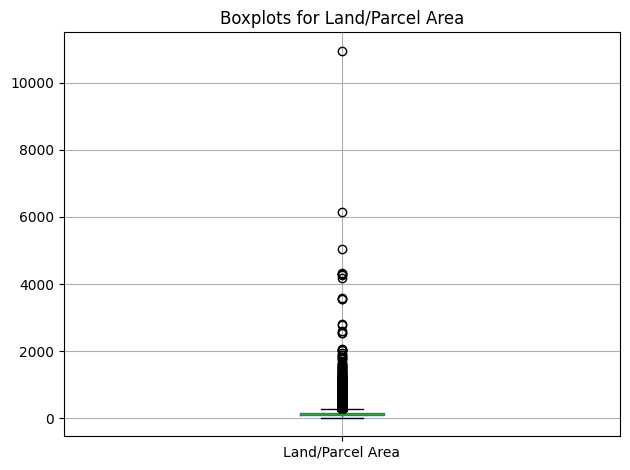

In [18]:
# Overall numeric data Boxplot for detecting outliers

df.select_dtypes(include='number').boxplot(figsize=(20, 8), rot=45, grid=False)
plt.title("Boxplots of Numeric Features")
plt.tight_layout()
plt.show()

print('\n\n')

# Boxplot for Transaction Price
df.boxplot(column=['Transaction Price'])
plt.title("Boxplots for Transaction Price")
plt.tight_layout()
plt.show()

print('\n\n')

# Boxplot Land/Parcel Area
df.boxplot(column=['Land/Parcel Area'])
plt.title("Boxplots for Land/Parcel Area")
plt.tight_layout()
plt.show()

print('\n\n')

# Boxplot Main Floor Area
df.boxplot(column=['Main Floor Area'])
plt.title("Boxplots for Main Floor Area")
plt.tight_layout()
plt.show()

print('\n\n')

# View outlier for Land/Parcel Area
outlier_LandArea = df[df['Land/Parcel Area']>220000]
print('\n\n', outlier_LandArea['Land/Parcel Area'])

# Remove outliers for Land/Parcel Area
LandArea_no_outlier = df[df['Land/Parcel Area']<=220000]
print('\n\n', LandArea_no_outlier['Land/Parcel Area'])

# Boxplot LandArea_no_outlier
LandArea_no_outlier.boxplot(column=['Land/Parcel Area'])
plt.title("Boxplots for Land/Parcel Area")
plt.tight_layout()
plt.show()

In [19]:
# Calculate Z-scores for Transaction Price

mean_val = df['Transaction Price'].mean()
std_val = df['Transaction Price'].std()
df['z_score'] = (df['Transaction Price'] - mean_val) / std_val

# Flag outliers (e.g., Z > 3 or Z < -3)
df['outlier'] = df['z_score'].abs() > 3

if df['outlier'].any():
    print("Outliers detected in 'Transaction Price':")
    print(df[df['outlier']])
else:
    print("No outliers detected in 'Transaction Price'.")


Outliers detected in 'Transaction Price':
                        Property Type     District               Mukim  \
17     1 - 1 1/2 Storey Semi-Detached  Johor Bahru  Bandar Johor Bahru   
301    1 - 1 1/2 Storey Semi-Detached  Johor Bahru               Pulai   
303    1 - 1 1/2 Storey Semi-Detached  Johor Bahru               Pulai   
5092        1 - 1 1/2 Storey Terraced  Johor Bahru              Tebrau   
6736   2 - 2 1/2 Storey Semi-Detached  Johor Bahru  Bandar Johor Bahru   
...                               ...          ...                 ...   
38151                        Detached  Johor Bahru              Tebrau   
38152                        Detached  Johor Bahru              Tebrau   
38153                        Detached  Johor Bahru              Tebrau   
38401                            Flat  Johor Bahru            Plentong   
38402                            Flat  Johor Bahru            Plentong   

       Scheme Name/Area            Road Name Month, Year of Transacti

In [20]:
# Calculate Z-scores for Main Floor Area

mean_val = df['Main Floor Area'].mean()
std_val = df['Main Floor Area'].std()
df['z_score'] = (df['Main Floor Area'] - mean_val) / std_val

# Flag outliers (e.g., Z > 3 or Z < -3)
df['outlier'] = df['z_score'].abs() > 3

if df['outlier'].any():
    print("Outliers detected in 'Main Floor Area':")
    print(df[df['outlier']])
    print("\n(Total no. of rows, Total no. of columns) = " + f"{df[df['outlier']].shape}")
else:
    print("No outliers detected in 'Main Floor Area'.")

Outliers detected in 'Main Floor Area':
                        Property Type     District   Mukim  Scheme Name/Area  \
301    1 - 1 1/2 Storey Semi-Detached  Johor Bahru   Pulai      LEISURE FARM   
302    1 - 1 1/2 Storey Semi-Detached  Johor Bahru   Pulai      LEISURE FARM   
303    1 - 1 1/2 Storey Semi-Detached  Johor Bahru   Pulai      LEISURE FARM   
304    1 - 1 1/2 Storey Semi-Detached  Johor Bahru   Pulai      LEISURE FARM   
5092        1 - 1 1/2 Storey Terraced  Johor Bahru  Tebrau  KEMPAS PERMATANG   
...                               ...          ...     ...               ...   
38091                        Detached  Johor Bahru  Tebrau     TMN ECO FLORA   
38092                        Detached  Johor Bahru  Tebrau     TMN ECO FLORA   
38117                        Detached  Johor Bahru  Tebrau  TMN MOUNT AUSTIN   
38118                        Detached  Johor Bahru  Tebrau  TMN MOUNT AUSTIN   
38122                        Detached  Johor Bahru  Tebrau         TMN MURNI   


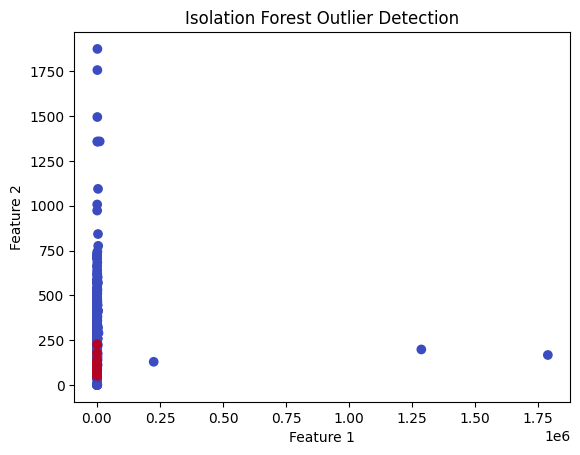

In [21]:
# Select numerical features only
X = df.select_dtypes(include='number')

# Fit Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # contamination = expected % of outliers
df['anomaly'] = iso_forest.fit_predict(X)

# Interpret results
# -1 = outlier, 1 = normal
outliers = df[df['anomaly'] == -1]
normal_data = df[df['anomaly'] == 1]

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=df['anomaly'], cmap='coolwarm')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Isolation Forest Outlier Detection")
plt.show()

Statistical Overview:

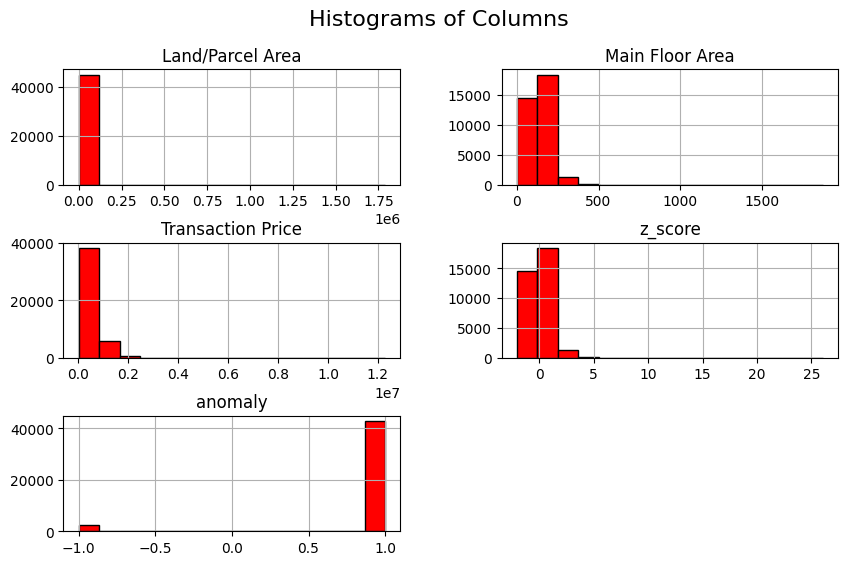

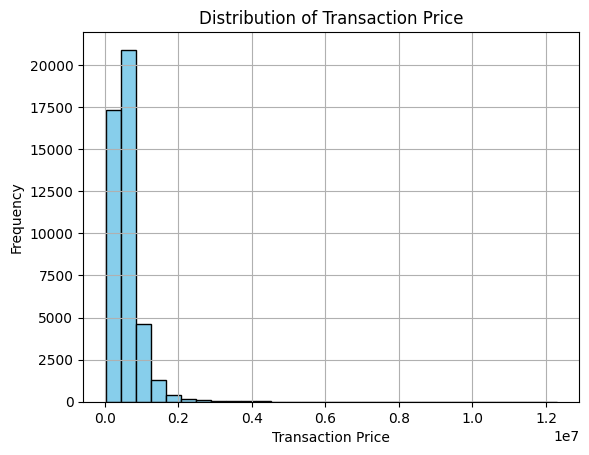

In [22]:
# Overall Histogram
df.hist(bins=15, figsize=(10, 6), color='red', edgecolor='black')
plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5)
plt.show()

print('\n\n')

# Transaction Price Histogram
plt.hist((df['Transaction Price']), bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Transaction Price')
plt.xlabel('Transaction Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Univariate Analysis:

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Land/Parcel Area,45021.0,2.337604e+02,10439.604830,15.000000,97.000000,130.060000,170.510000,1.788888e+06
Main Floor Area,34469.0,1.379532e+02,66.619154,0.000000,85.000000,133.000000,169.000000,1.875000e+03
Transaction Price,45021.0,5.788568e+05,425388.563336,22000.000000,350000.000000,498000.000000,692000.000000,1.228800e+07
z_score,34469.0,5.277175e-17,1.000000,-2.070774,-0.794865,-0.074351,0.466034,2.607428e+01
anomaly,45021.0,9.000022e-01,0.435890,-1.000000,1.000000,1.000000,1.000000,1.000000e+00


In [24]:
df.mode()

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,z_score,outlier,anomaly
0,2 - 2 1/2 Storey Terraced,Johor Bahru,Pulai,TMN BUKIT INDAH,,April 2023,Freehold,143.0,sq.m,130.0,sq.m,,500000.0,-0.119383,False,1


In [25]:
df.median(numeric_only=True)

,0
Land/Parcel Area,130.060000
Main Floor Area,133.000000
Transaction Price,498000.000000
z_score,-0.074351
outlier,0.000000
anomaly,1.000000


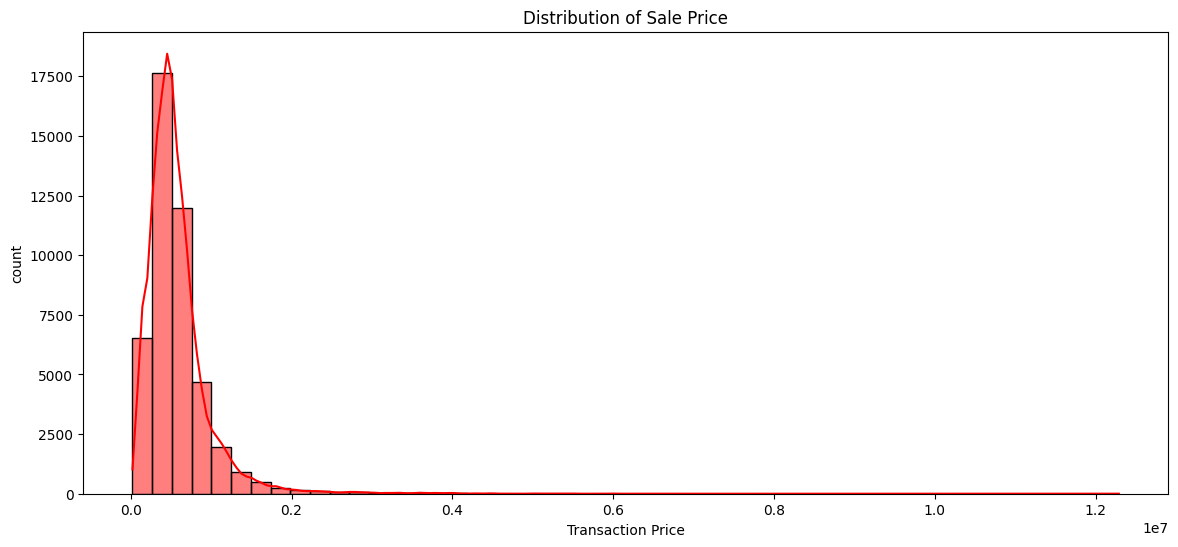


Skewness of Transaction Price: 4.75
Kurtosis of Transaction Price: 54.73





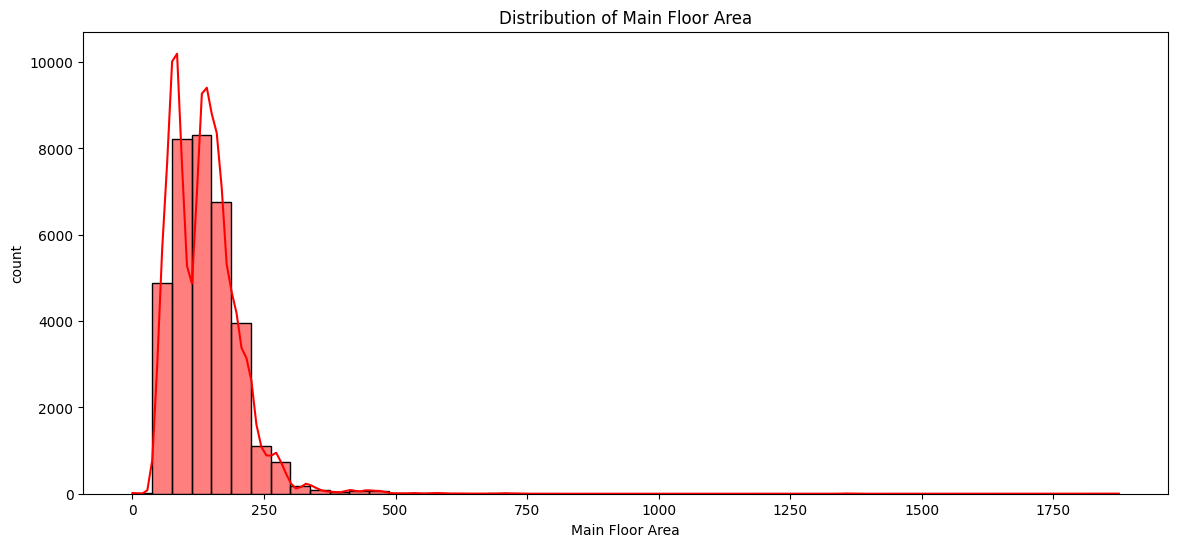


Skewness of Main Floor Area: 3.28
Kurtosis of Main Floor Area: 46.33


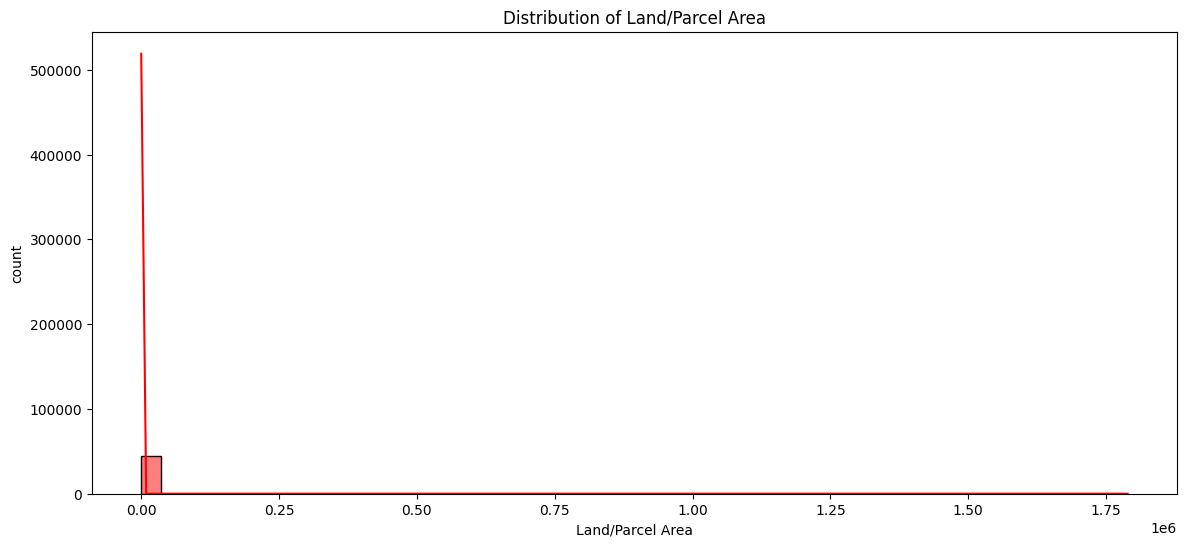


Skewness of Land/Parcel Area: 153.53
Kurtosis of Land/Parcel Area: 24271.04





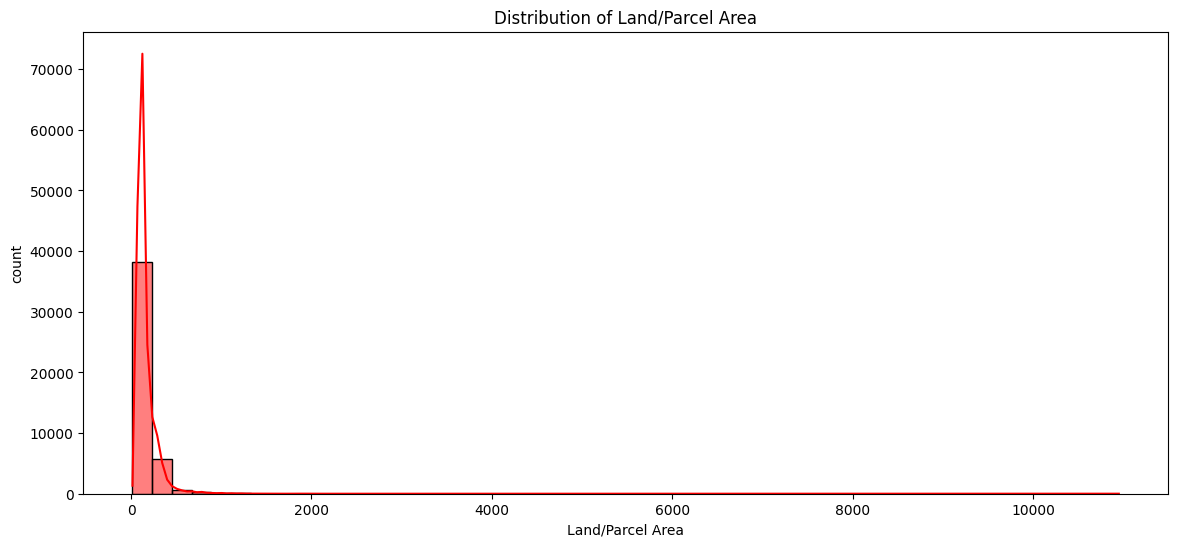


Skewness of Land/Parcel Area: 153.53
Kurtosis of Land/Parcel Area: 24271.04





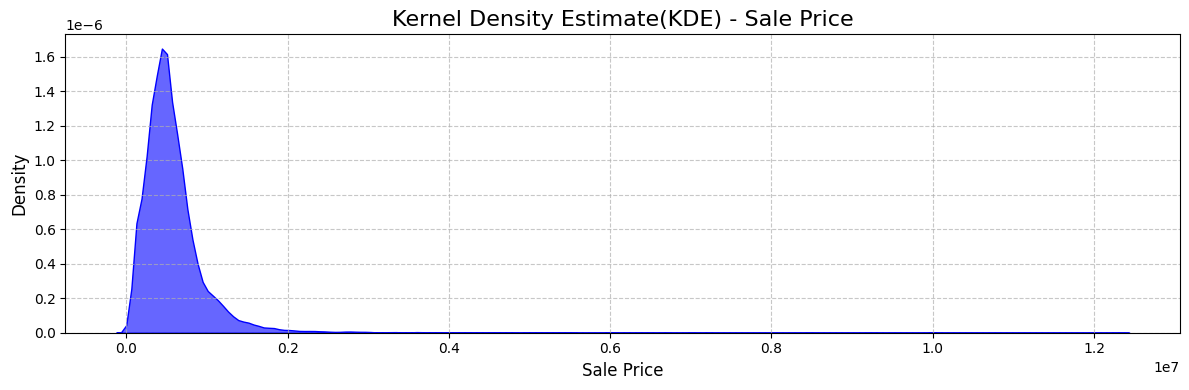

In [26]:
# Distribution of transaction price
plt.figure(figsize=(14, 6))
sns.histplot(df['Transaction Price'], bins=50, kde=True, color='red')
plt.title('Distribution of Sale Price')
plt.xlabel('Transaction Price')
plt.ylabel('count')
plt.show()

print(f"\nSkewness of Transaction Price: {df['Transaction Price'].skew():.2f}")
print(f"Kurtosis of Transaction Price: {df['Transaction Price'].kurt():.2f}")

print('\n\n')

# Distribution of Main Floor Area
plt.figure(figsize=(14, 6))
sns.histplot(df['Main Floor Area'], bins=50, kde=True, color='red')
plt.title('Distribution of Main Floor Area')
plt.xlabel('Main Floor Area')
plt.ylabel('count')
plt.show()

print(f"\nSkewness of Main Floor Area: {df['Main Floor Area'].skew():.2f}")
print(f"Kurtosis of Main Floor Area: {df['Main Floor Area'].kurt():.2f}")

# Distribution of Land/Parcel Area (with outliers)
plt.figure(figsize=(14, 6))
sns.histplot(df['Land/Parcel Area'], bins=50, kde=True, color='red')
plt.title('Distribution of Land/Parcel Area')
plt.xlabel('Land/Parcel Area')
plt.ylabel('count')
plt.show()

print(f"\nSkewness of Land/Parcel Area: {df['Land/Parcel Area'].skew():.2f}")
print(f"Kurtosis of Land/Parcel Area: {df['Land/Parcel Area'].kurt():.2f}")

print('\n\n')

# Distribution of Land/Parcel Area (without otliers)
plt.figure(figsize=(14, 6))
sns.histplot(LandArea_no_outlier['Land/Parcel Area'], bins=50, kde=True, color='red')
plt.title('Distribution of Land/Parcel Area')
plt.xlabel('Land/Parcel Area')
plt.ylabel('count')
plt.show()

print(f"\nSkewness of Land/Parcel Area: {df['Land/Parcel Area'].skew():.2f}")
print(f"Kurtosis of Land/Parcel Area: {df['Land/Parcel Area'].kurt():.2f}")


print('\n\n')

# KDE plot
plt.figure(figsize=(12,	4))
sns.kdeplot(df['Transaction Price'], fill=True,	color='blue', alpha=0.6)
plt.title(f'Kernel Density Estimate(KDE) - Sale Price',	fontsize=16)
plt.xlabel('Sale Price', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Bivariate Analysis:**

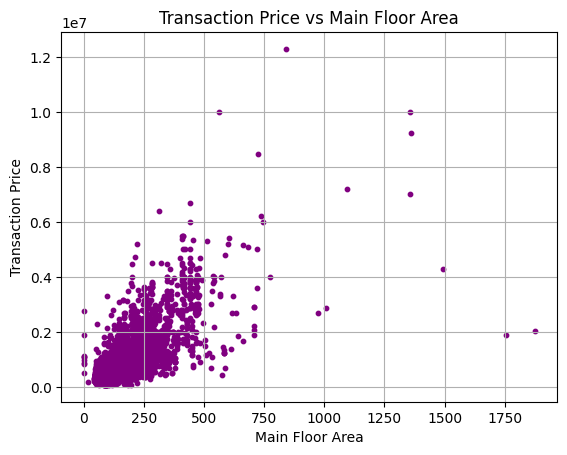

<Figure size 1400x400 with 0 Axes>

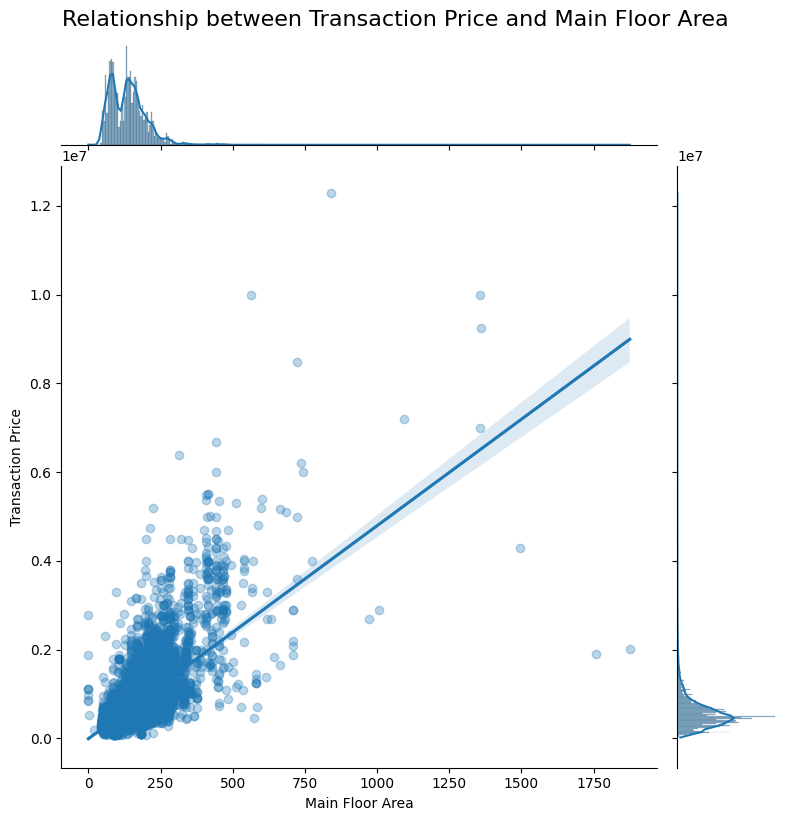

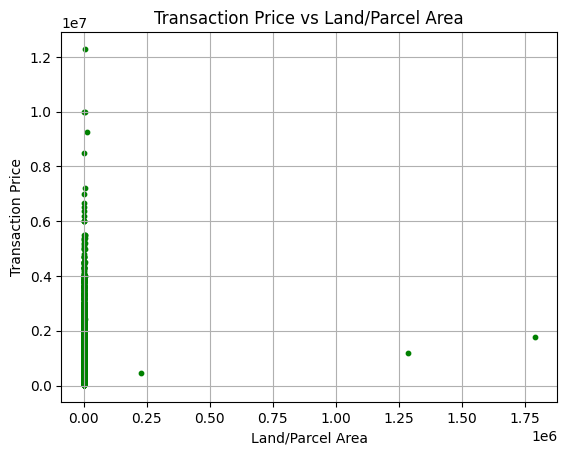

In [27]:
# Transaction Price vs Main Floor Area
df.plot.scatter(x='Main Floor Area', y='Transaction Price', s=10, c='purple')
plt.title('Transaction Price vs Main Floor Area')
plt.xlabel('Main Floor Area')
plt.ylabel('Transaction Price')
plt.grid(True)
plt.show()

print('\n\n')

plt.figure(figsize=(14, 4))
sns.jointplot(x='Main Floor Area', y='Transaction Price', data=df, kind='reg', height=8, scatter_kws={'alpha':0.3})
plt.suptitle('Relationship between Transaction Price and Main Floor Area', y=1.02, fontsize=16)
plt.show()

print('\n\n')

# Transaction Price vs Land/Parcel Area
df.plot.scatter(x='Land/Parcel Area', y='Transaction Price', s=10, c='green')
plt.title('Transaction Price vs Land/Parcel Area')
plt.xlabel('Land/Parcel Area')
plt.ylabel('Transaction Price')
plt.grid(True)
plt.show()


"\nplt.figure(figsize=(14, 4))\nsns.jointplot(data=df, kind='reg', height=8, scatter_kws={'alpha':0.3})\nplt.suptitle('Relationship between Two Variables', y=1.02, fontsize=16)\nplt.show()\n"

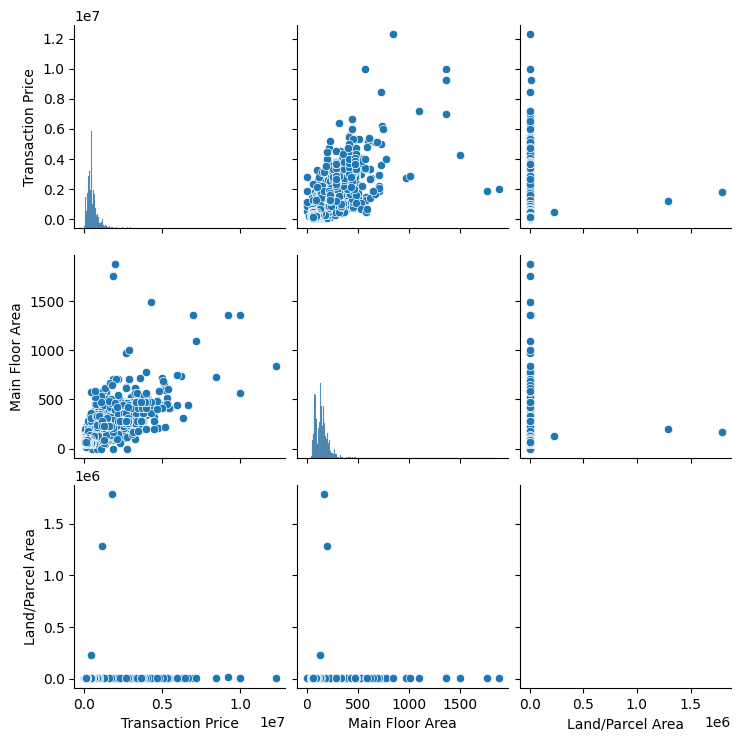

In [28]:
sns.pairplot(df[['Transaction Price','Main Floor Area','Land/Parcel Area']])
# sns.pairplot(df[['Transaction Price','Main Floor Area','Land/Parcel Area']], kind='reg', diag_kind='kde')
'''
plt.figure(figsize=(14, 4))
sns.jointplot(data=df, kind='reg', height=8, scatter_kws={'alpha':0.3})
plt.suptitle('Relationship between Two Variables', y=1.02, fontsize=16)
plt.show()
'''

**Analysis Housing < RM 1 million**

475000.0


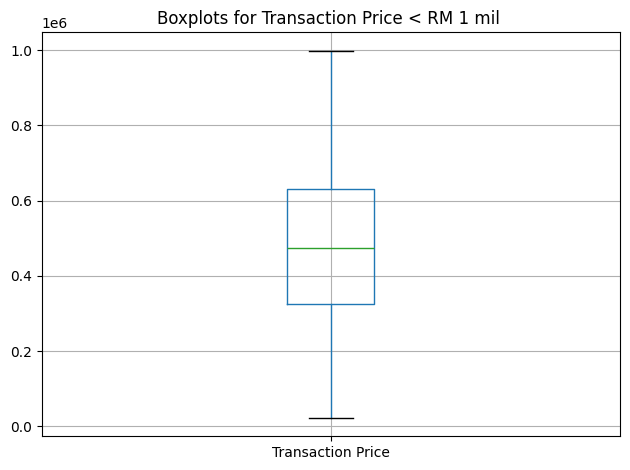

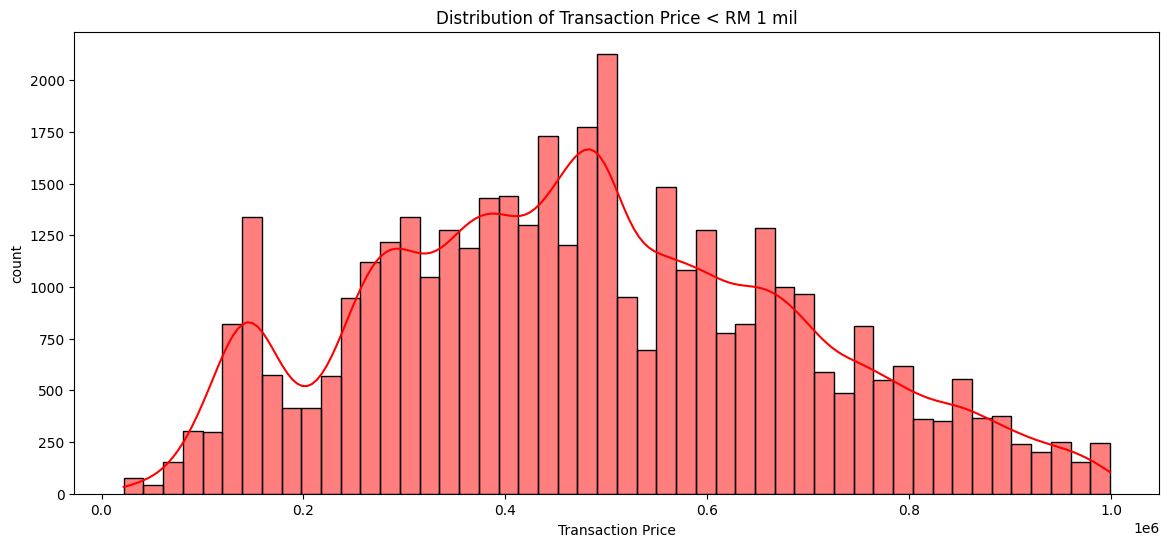

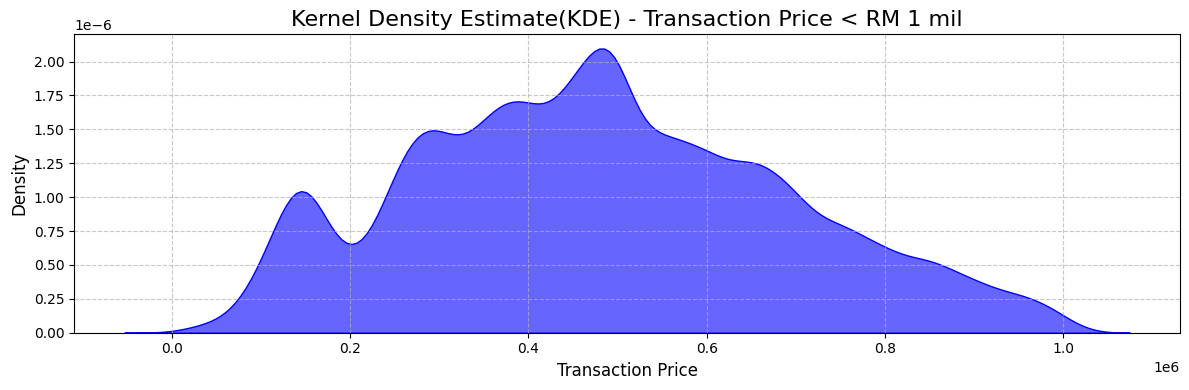

In [29]:
aff = df[df['Transaction Price'] < 1000000]
print(aff['Transaction Price'].median())
aff.boxplot('Transaction Price')
plt.title("Boxplots for Transaction Price < RM 1 mil ")
plt.tight_layout()
plt.show()

print('\n\n')

plt.figure(figsize=(14, 6))
sns.histplot(aff['Transaction Price'], bins=50, kde=True, color='red')
plt.title('Distribution of Transaction Price < RM 1 mil')
plt.xlabel('Transaction Price')
plt.ylabel('count')
plt.show()

print('\n\n')

plt.figure(figsize=(12,	4))
sns.kdeplot(aff['Transaction Price'], fill=True,	color='blue', alpha=0.6)
plt.title(f'Kernel Density Estimate(KDE) - Transaction Price < RM 1 mil',	fontsize=16)
plt.xlabel('Transaction Price', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
